# B3 — Local Linear Trend Model

**Reference:** W&H: Introduction to the Dynamic Regression Model; Petris: A Simple Example

**Concepts introduced:**
- Two-dimensional state: (level, slope)
- Evolution matrix G encoding linear trend
- Comparing local level vs LLT on trending data
- LLT forecast fan: linear projection vs flat local level

In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from engine.models import make_local_level, make_local_linear_trend
from engine.filter import kalman_filter
from engine.smoother import rts_smoother
from engine.simulate import simulate
from engine.forecast import forecast_horizon

## 1. State equations

The **local linear trend** (LLT) model has a 2D state $\theta_t = (\mu_t, \beta_t)'$
representing level and slope (W&H: Introduction to the Dynamic Regression Model):

$$\mu_t = \mu_{t-1} + \beta_{t-1} + w_{1t}, \quad w_{1t} \sim N(0, W_\text{level})$$
$$\beta_t = \beta_{t-1} + w_{2t}, \quad w_{2t} \sim N(0, W_\text{slope})$$

Written as a DLM with:

$$G = \begin{pmatrix} 1 & 1 \\ 0 & 1 \end{pmatrix}, \quad
F = \begin{pmatrix} 1 & 0 \end{pmatrix}, \quad
W = \begin{pmatrix} W_\text{level} & 0 \\ 0 & W_\text{slope} \end{pmatrix}$$

$F$ picks out the level component as the observation.
When $W_\text{slope} \to 0$, the slope becomes a fixed constant (no slope evolution).

In [2]:
# Print the matrices to verify
spec_llt = make_local_linear_trend(V=1.0, W_level=0.1, W_slope=0.01)
print("F =\n", spec_llt.F)
print("G =\n", spec_llt.G)
print("W =\n", spec_llt.W)
print("State dim d =", spec_llt.G.shape[0])

F =
 [[1. 0.]]
G =
 [[1. 1.]
 [0. 1.]]
W =
 [[0.1  0.  ]
 [0.   0.01]]
State dim d = 2


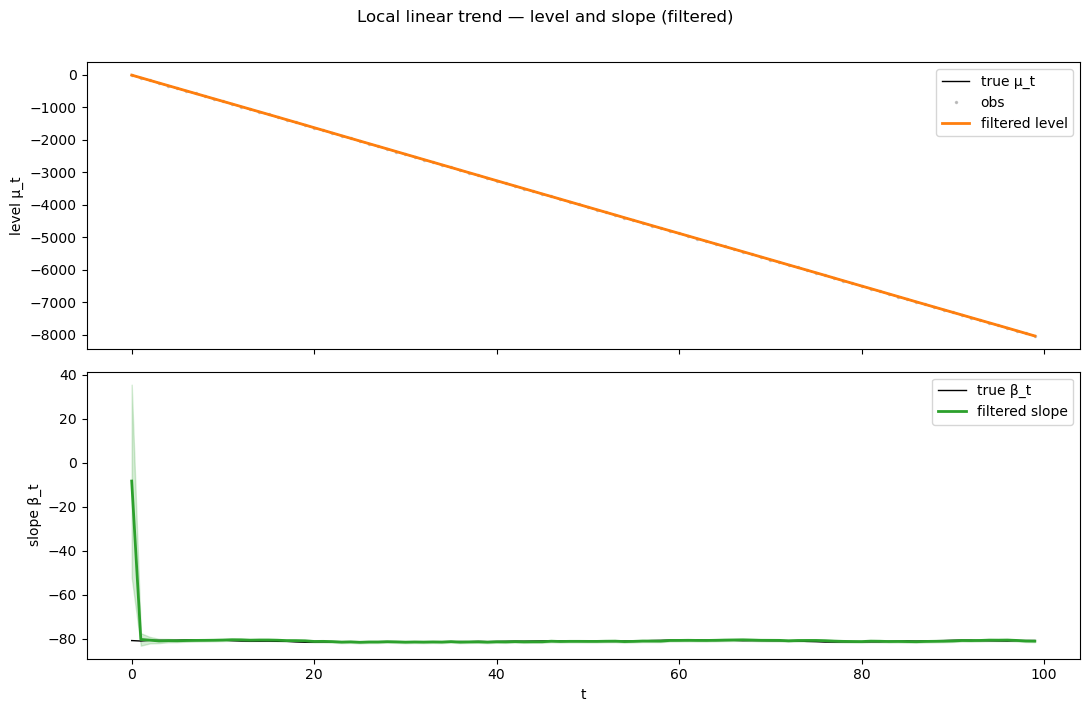

In [3]:
sim_llt = simulate(spec_llt, n=100, seed=3)
fr_llt  = kalman_filter(spec_llt, sim_llt.y)
sr_llt  = rts_smoother(spec_llt, fr_llt)

t = np.arange(100)
std_mu = np.sqrt(fr_llt.C[:, 0, 0])
std_bt = np.sqrt(fr_llt.C[:, 1, 1])

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Level
axes[0].plot(t, sim_llt.theta_true[:, 0], "k-", lw=1, label="true μ_t")
axes[0].plot(t, sim_llt.y[:, 0], ".", ms=3, alpha=0.4, color="grey", label="obs")
axes[0].plot(t, fr_llt.m[:, 0], "C1-", lw=2, label="filtered level")
axes[0].fill_between(t, fr_llt.m[:, 0]-1.96*std_mu,
                        fr_llt.m[:, 0]+1.96*std_mu, alpha=0.2, color="C1")
axes[0].set_ylabel("level μ_t"); axes[0].legend()

# Slope
axes[1].plot(t, sim_llt.theta_true[:, 1], "k-", lw=1, label="true β_t")
axes[1].plot(t, fr_llt.m[:, 1], "C2-", lw=2, label="filtered slope")
axes[1].fill_between(t, fr_llt.m[:, 1]-1.96*std_bt,
                        fr_llt.m[:, 1]+1.96*std_bt, alpha=0.2, color="C2")
axes[1].set_xlabel("t"); axes[1].set_ylabel("slope β_t"); axes[1].legend()

plt.suptitle("Local linear trend — level and slope (filtered)", y=1.01)
plt.tight_layout()
plt.show()

## 2. Local level vs LLT on trending data

The local level model assumes no systematic trend — it treats the state as a
random walk. On data with a persistent slope, local level's filtered mean lags
behind the true state because it can't anticipate the trend direction.

Local level  log-lik: -827465.01
LLT          log-lik: -174.12


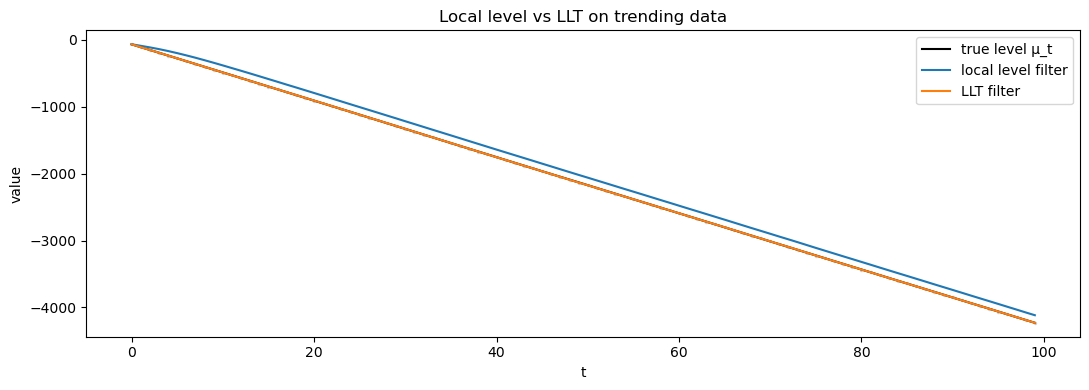

In [4]:
# True slope is ~0.3 per step
spec_compare = make_local_linear_trend(V=1.0, W_level=0.05, W_slope=0.001)
sim_trend = simulate(spec_compare, n=100, seed=5)

fr_ll  = kalman_filter(make_local_level(V=1.0, W_level=0.1), sim_trend.y)
fr_llt2 = kalman_filter(spec_compare, sim_trend.y)

print(f"Local level  log-lik: {fr_ll.loglik:.2f}")
print(f"LLT          log-lik: {fr_llt2.loglik:.2f}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t, sim_trend.theta_true[:, 0], "k-", lw=1.5, label="true level μ_t")
ax.plot(t, sim_trend.y[:, 0], ".", ms=3, alpha=0.3, color="grey")
ax.plot(t, fr_ll.m[:, 0], "C0-", lw=1.5, label="local level filter")
ax.plot(t, fr_llt2.m[:, 0], "C1-", lw=1.5, label="LLT filter")
ax.set(xlabel="t", ylabel="value",
       title="Local level vs LLT on trending data")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Forecast comparison

The LLT forecast is linear: the level grows by the estimated slope $\hat\beta_T$ at
each step. The local level forecast is flat (random-walk has zero expected increment).

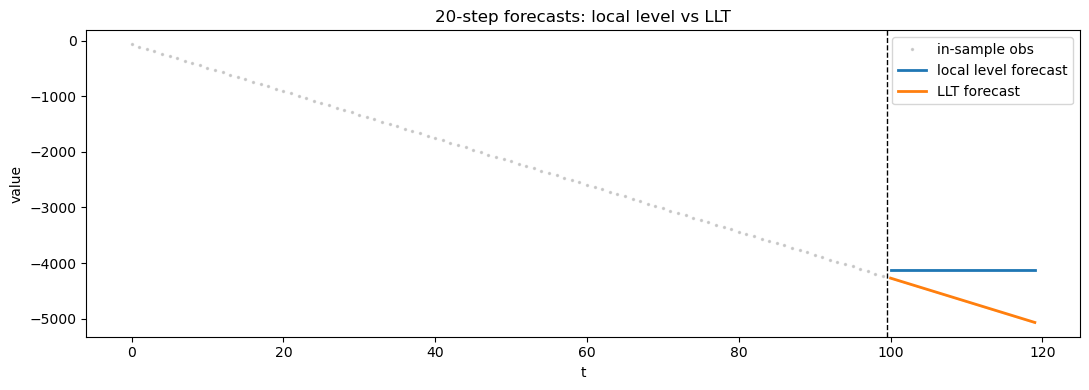

In [5]:
fc_ll   = forecast_horizon(make_local_level(V=1.0, W_level=0.1), fr_ll, h=20)
fc_llt2 = forecast_horizon(spec_compare, fr_llt2, h=20)

t_fc = np.arange(100, 120)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t, sim_trend.y[:, 0], ".", ms=3, alpha=0.3, color="grey", label="in-sample obs")
ax.plot(t_fc, fc_ll.means[:, 0],  "C0-", lw=2, label="local level forecast")
ax.fill_between(t_fc, fc_ll.lower[:, 0], fc_ll.upper[:, 0], alpha=0.2, color="C0")
ax.plot(t_fc, fc_llt2.means[:, 0], "C1-", lw=2, label="LLT forecast")
ax.fill_between(t_fc, fc_llt2.lower[:, 0], fc_llt2.upper[:, 0], alpha=0.2, color="C1")
ax.axvline(99.5, color="k", ls="--", lw=1)
ax.set(xlabel="t", ylabel="value", title="20-step forecasts: local level vs LLT")
ax.legend()
plt.tight_layout()
plt.show()

## Exercises

**Exercise 1** — Set `W_slope=0` (use a very small value like `1e-9` to stay
numerically stable) in `make_local_linear_trend`. Filter the same trending series.
Does the slope converge? Print `fr.m[:, 1]` over time to see it stabilise around
the true slope.

**Exercise 2** — Increase `W_slope` from 0.01 to 1.0. How does the slope trace
`fr.m[:, 1]` change? Does it track the true slope more or less closely?

**Exercise 3** — Compute log-likelihoods for both models on `sim_trend`. Which wins?
Does that match the visual evidence?

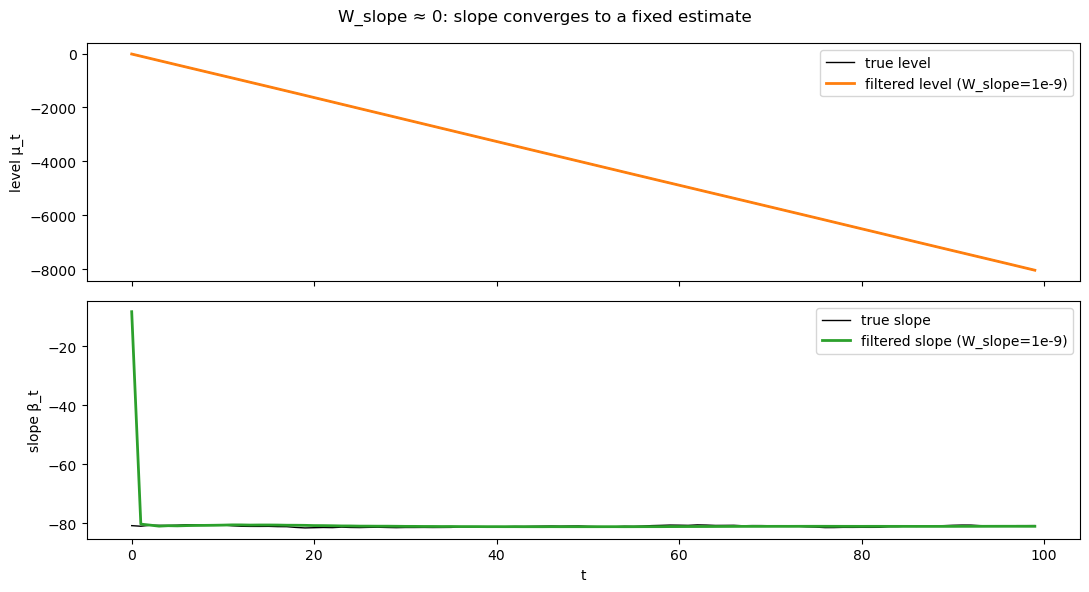

Slope estimates (first 10): [ -8.2945 -80.3557 -80.6951 -81.0451 -80.8926 -80.9494 -80.8595 -80.8128
 -80.7882 -80.75  ]
Slope estimates (last 10):  [-81.1211 -81.1123 -81.1113 -81.1066 -81.0979 -81.0946 -81.0886 -81.0908
 -81.0971 -81.0983]
Slope std (last 10):        [0.034381 0.03418  0.033982 0.033788 0.033596 0.033408 0.033224 0.033042
 0.032863 0.032687]
Yes: slope converges — W_slope=0 forces it to a constant value


In [6]:
# Exercise 1 — W_slope ≈ 0 (use 1e-9): slope converges to a fixed value
spec_fixed_slope = make_local_linear_trend(V=1.0, W_level=0.1, W_slope=1e-9)
fr_fixed = kalman_filter(spec_fixed_slope, sim_llt.y)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
t = np.arange(100)

axes[0].plot(t, sim_llt.theta_true[:, 0], 'k-', lw=1, label='true level')
axes[0].plot(t, fr_fixed.m[:, 0], 'C1-', lw=2, label='filtered level (W_slope=1e-9)')
axes[0].set_ylabel('level μ_t'); axes[0].legend()

axes[1].plot(t, sim_llt.theta_true[:, 1], 'k-', lw=1, label='true slope')
axes[1].plot(t, fr_fixed.m[:, 1], 'C2-', lw=2, label='filtered slope (W_slope=1e-9)')
axes[1].set_xlabel('t'); axes[1].set_ylabel('slope β_t'); axes[1].legend()

plt.suptitle('W_slope ≈ 0: slope converges to a fixed estimate')
plt.tight_layout()
plt.show()

# Show slope values — they stabilise after a few steps
print('Slope estimates (first 10):', fr_fixed.m[:10, 1].round(4))
print('Slope estimates (last 10): ', fr_fixed.m[-10:, 1].round(4))
print('Slope std (last 10):       ', np.sqrt(fr_fixed.C[-10:, 1, 1]).round(6))
print('Yes: slope converges — W_slope=0 forces it to a constant value')


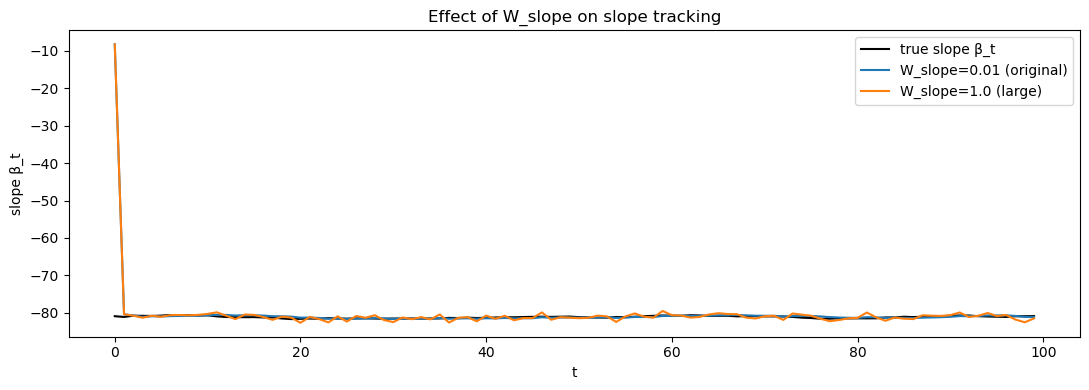

Slope std with W_slope=0.01 (last 20): 0.2355
Slope std with W_slope=1.0  (last 20): 1.2802
Larger W_slope → slope is more variable, tracks slope changes more closely


In [7]:
# Exercise 2 — W_slope = 1.0 (large): slope tracks data more aggressively
spec_large_slope = make_local_linear_trend(V=1.0, W_level=0.1, W_slope=1.0)
fr_large = kalman_filter(spec_large_slope, sim_llt.y)

# Compare W_slope=0.01 (original) vs 1.0 (large)
spec_orig = make_local_linear_trend(V=1.0, W_level=0.1, W_slope=0.01)
fr_orig   = kalman_filter(spec_orig, sim_llt.y)

t = np.arange(100)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t, sim_llt.theta_true[:, 1], 'k-', lw=1.5, label='true slope β_t')
ax.plot(t, fr_orig.m[:, 1], 'C0-', lw=1.5, label='W_slope=0.01 (original)')
ax.plot(t, fr_large.m[:, 1], 'C1-', lw=1.5, label='W_slope=1.0 (large)')
ax.set(xlabel='t', ylabel='slope β_t',
       title='Effect of W_slope on slope tracking')
ax.legend()
plt.tight_layout()
plt.show()

print('Slope std with W_slope=0.01 (last 20):', np.sqrt(fr_orig.C[-20:, 1, 1]).mean().round(4))
print('Slope std with W_slope=1.0  (last 20):', np.sqrt(fr_large.C[-20:, 1, 1]).mean().round(4))
print('Larger W_slope → slope is more variable, tracks slope changes more closely')


In [8]:
# Exercise 3 — Compare log-likelihoods: local level vs LLT on sim_trend
loglik_ll  = kalman_filter(make_local_level(V=1.0, W_level=0.1), sim_trend.y).loglik
loglik_llt = kalman_filter(spec_compare, sim_trend.y).loglik

print(f'Local level log-lik: {loglik_ll:.2f}')
print(f'LLT         log-lik: {loglik_llt:.2f}')
print(f'LLT wins by: {loglik_llt - loglik_ll:.2f} log-units')
print()
print('LLT wins — matching the visual evidence that LLT tracks the true trend.')
print('Local level lags behind and generates higher prediction errors for trending data.')


Local level log-lik: -827465.01
LLT         log-lik: -174.12
LLT wins by: 827290.89 log-units

LLT wins — matching the visual evidence that LLT tracks the true trend.
Local level lags behind and generates higher prediction errors for trending data.
